In [73]:
import sys, platform, hashlib, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# --- Tekrar üretilebilirlik için seed sabitle ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
print(f"Python: {sys.version.split()[0]} | Platform: {platform.platform()}")

Python: 3.12.13 | Platform: Linux-6.6.122+-x86_64-with-glibc2.35


In [74]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [76]:
df.dropna(inplace=True)
df.drop("customerID", axis=1, inplace=True)
df.head()



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [77]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [78]:
df.head()
#df["Contract"].unique()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [79]:
objects = ["Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","PaperlessBilling","Churn"]
label_encoder = LabelEncoder()
for obj in objects:
  df[obj] = label_encoder.fit_transform(df[obj])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,1,0,0,2,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,0,2,0,2,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,0,2,2,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,1,0,2,0,2,2,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,1,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [80]:
df.describe().head().T

,count,mean,std,min,25%
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000
Partner,7032.0,0.482509,0.499729,0.00,0.0000
Dependents,7032.0,0.298493,0.457629,0.00,0.0000
tenure,7032.0,32.421786,24.545260,1.00,9.0000
PhoneService,7032.0,0.903299,0.295571,0.00,1.0000
MultipleLines,7032.0,0.940557,0.948627,0.00,0.0000
InternetService,7032.0,0.872582,0.737271,0.00,0.0000
OnlineSecurity,7032.0,0.789249,0.859962,0.00,0.0000
OnlineBackup,7032.0,0.905859,0.880394,0.00,0.0000
DeviceProtection,7032.0,0.903868,0.880178,0.00,0.0000


In [81]:
print("eksik değerler toplamı: ", df.isnull().sum())
for col in df.isnull().sum():
  if (col != 0):
     print("kirli data")
print("\nTemiz veri.")

eksik değerler toplamı:  gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Temiz veri.


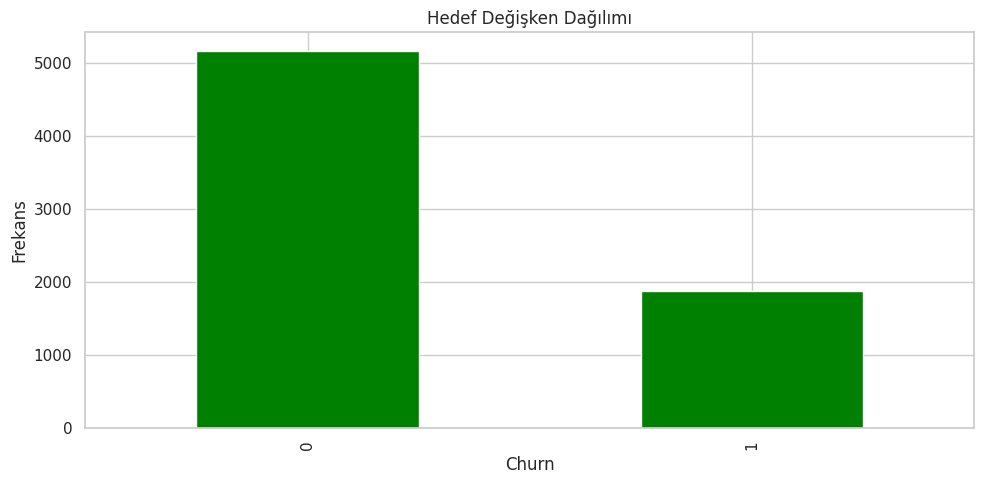

In [82]:
fig, ax = plt.subplots(figsize=(10,5))
df["Churn"].value_counts().plot(kind="bar", color = "green", ax=ax)
ax.set_title("Hedef Değişken Dağılımı"); ax.set_xlabel("Churn"); ax.set_ylabel("Frekans")
plt.tight_layout(); plt.show()


In [83]:
for col in df.columns:
  if df[col].isnull().any():
    print(col)
y = df["Churn"]
X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)

if not pd.api.types.is_numeric_dtype(y):
  le = LabelEncoder()
  y = le.fit_transform(y) ###########


print(X.shape,'\n' ,y.shape)

(7032, 22) 
 (7032,)


In [84]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print(f"Eğitim seti: {len(X_tr)} | Test seti: {len(X_te)}")

Eğitim seti: 5274 | Test seti: 1758


In [85]:
def evaluate_model(model, name):
  model.fit(X_tr, y_tr)
  y_pred = model.predict(X_te)
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
  cv_skor = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy")
  m = {
        "Model": name,
        "Doğruluk (Accuracy)": accuracy_score(y_te, y_pred),
        "Kesinlik (Precision)": precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "Duyarlılık (Recall)": recall_score(y_te, y_pred, average="weighted"),
        "F1 Skoru": f1_score(y_te, y_pred, average="weighted"),
        "CV Ortalama": cv_skor.mean(),
        "CV Std": cv_skor.std(),
    }
  if len(np.unique(y_tr)) == 2:
        m["ROC-AUC"] = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

  print(f"--- {name} ---")
  print(classification_report(y_te, y_pred, zero_division=0))
  return model, y_pred, m

dt_model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                                  class_weight="balanced", random_state=SEED)
rf_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  class_weight="balanced", n_jobs=-1, random_state=SEED)

dt_model, dt_pred, dt_m = evaluate_model(dt_model, "Decision Tree")
rf_model, rf_pred, rf_m = evaluate_model(rf_model, "Random Forest")


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1291
           1       0.50      0.77      0.61       467

    accuracy                           0.74      1758
   macro avg       0.70      0.75      0.70      1758
weighted avg       0.79      0.74      0.75      1758

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1291
           1       0.59      0.62      0.60       467

    accuracy                           0.78      1758
   macro avg       0.72      0.73      0.73      1758
weighted avg       0.79      0.78      0.78      1758



In [86]:
table = pd.DataFrame([dt_m, rf_m]).set_index("Model").round(4)
table.to_csv("model_karsilastirma.csv")
table

,Doğruluk (Accuracy),Kesinlik (Precision),Duyarlılık (Recall),F1 Skoru,CV Ortalama,CV Std,ROC-AUC
Model,,,,,,,
Decision Tree,0.7355,0.7914,0.7355,0.7492,0.7363,0.0126,0.8153
Random Forest,0.7827,0.7874,0.7827,0.7848,0.7869,0.0123,0.8299


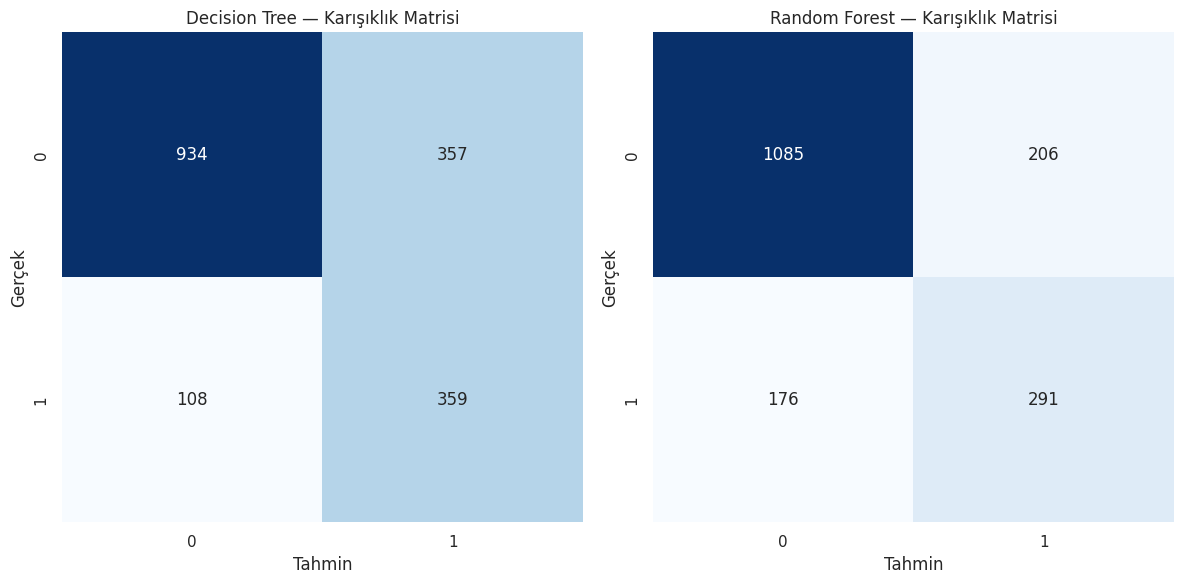

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax,(name, pred) in zip(axes, [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]):
  cm = confusion_matrix(y_te, pred)
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
  ax.set_title(f"{name} — Karışıklık Matrisi")
  ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
plt.tight_layout(); plt.show()


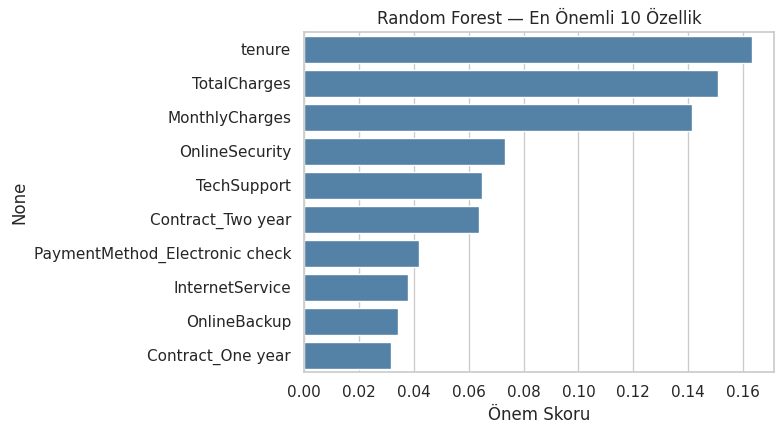

In [88]:
onem = pd.Series(rf_model.feature_importances_, index=X.columns).nlargest(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=onem.values, y=onem.index, color="steelblue", ax=ax)
ax.set_title("Random Forest — En Önemli 10 Özellik"); ax.set_xlabel("Önem Skoru")
plt.tight_layout(); plt.show()

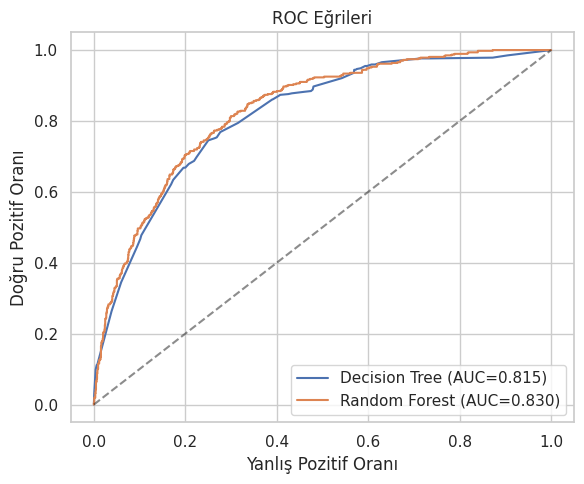

In [89]:
if len(np.unique(y_te)) == 2:
    fig, ax = plt.subplots(figsize=(6, 5))
    for model, name in [(dt_model, "Decision Tree"), (rf_model, "Random Forest")]:
        proba = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, proba)
        ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te, proba):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title("ROC Eğrileri")
    ax.set_xlabel("Yanlış Pozitif Oranı"); ax.set_ylabel("Doğru Pozitif Oranı")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print("Çok sınıflı problem: ROC eğrisi atlandı.")

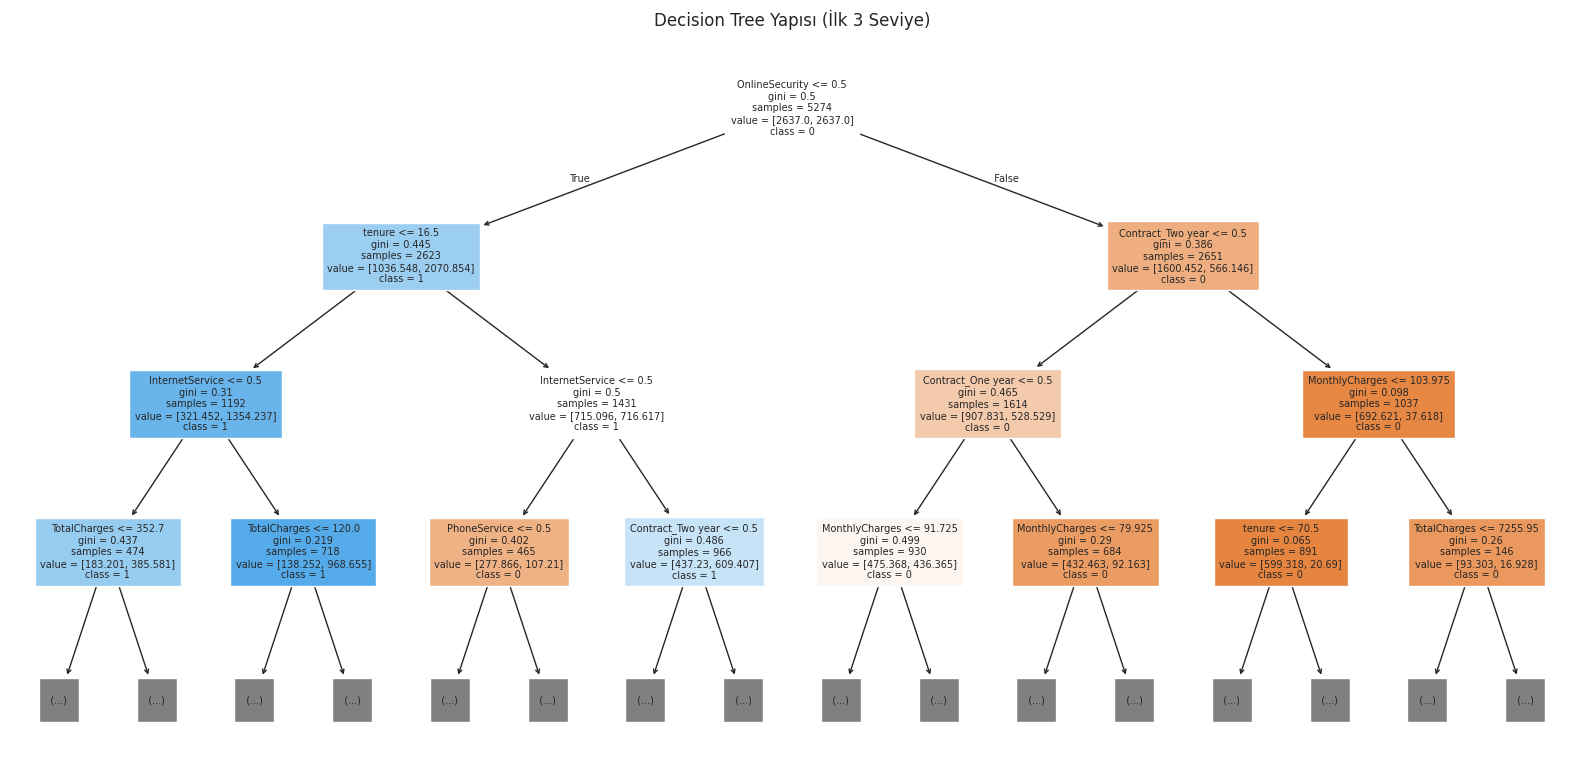

In [90]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(dt_model, max_depth=3, feature_names=list(X.columns), filled=True,
          fontsize=7, ax=ax, class_names=[str(cl) for cl in np.unique(y_te)])
ax.set_title("Decision Tree Yapısı (İlk 3 Seviye)")
plt.tight_layout(); plt.show()